In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Input, Activation
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [2]:
import numpy as np
from pathlib import Path

In [6]:
import sys
sys.path.append("..")
from dataset import make_sr_dataset
import matplotlib.pyplot as plt

2.20.0


In [7]:
np.random.seed(7)

In [8]:
HR_SIZE = 128
SCALE = 2
LR_SIZE = 64
BATCH = 8
EPOCHS = 10

In [16]:
ROOT = Path("../data/raw/Flickr2K")
path = [str(p) for p in ROOT.glob('*.png')]

In [17]:
print(path[:5])

['../data/raw/Flickr2K/001927.png', '../data/raw/Flickr2K/001099.png', '../data/raw/Flickr2K/000387.png', '../data/raw/Flickr2K/002590.png', '../data/raw/Flickr2K/002584.png']


In [18]:
np.random.shuffle(path)

In [19]:
train_paths = path[:2120]
val_paths = path[2120:2120+265]
test_paths = path[2120+265 :]

In [20]:
print(len(train_paths))
print(len(val_paths))
print(len(test_paths))

2120
265
265


In [21]:
ds_train = make_sr_dataset(train_paths,HR_SIZE,SCALE,BATCH,True)
ds_val = make_sr_dataset(val_paths,HR_SIZE,SCALE,BATCH,False)

In [22]:
input_shape = (64,64,3)
kernel_size = 3
layer_filters = [32, 64,128]

In [23]:
inputs = Input(shape = input_shape,name= 'encoder_input')
x = inputs

for filters in layer_filters:
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)


shape = K.int_shape(x)

encoder = Model(inputs,x,name = 'encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,768 (1.83 MB)

 Trainable params: 480,768 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
decoder_input = Input(shape=(8,8,128))
x = decoder_input
for filters in layer_filters[::-1]:
    x = Conv2DTranspose(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

x = Conv2DTranspose(filters = 3,kernel_size = kernel_size, strides = 2,padding= 'same')(x)
#x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

outputs = Activation('sigmoid',name = 'decoder_output')(x)
decoder = Model(inputs = decoder_input, outputs = outputs, name = 'decoder')

decoder.summary(line_length = 110)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                       │ (None, 8, 8, 128)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose (Conv2DTranspose)             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_9 (Conv2D)                              │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_10 (Conv2D)                             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose)           │ (None, 32, 32, 64)                  │              73,792 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_11 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_12 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose)           │ (None, 64, 64, 32)                  │              18,464 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_13 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_14 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose)           │ (None, 128, 128, 3)                 │                 867 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ decoder_output (Activation)                    │ (None, 128, 128, 3)                 │                   0 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 628,227 (2.40 MB)

 Trainable params: 628,227 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
autoencoder = Model(inputs,decoder(encoder(inputs)),name = 'autoencoder')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 8, 8, 128)      │       480,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       628,227 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,995 (4.23 MB)

 Trainable params: 1,108,995 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
def psnr_metrics(y_true,y_pred):
    return tf.image.psnr(y_true,y_pred,max_val = 1.0)

In [33]:
#Path("../models").mkdir(parents=True, exist_ok=True)

#autoencoder.save("../models/sr_autoencoder.keras")

#print("Model saved.")

In [27]:
autoencoder.compile(loss='MAE', metrics = [psnr_metrics],optimizer='adam')

In [28]:
history = autoencoder.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20,
    verbose=1
)

Epoch 1/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 0.1438 - psnr_metrics: 16.0774 - val_loss: 0.0992 - val_psnr_metrics: 18.7762
Epoch 2/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - loss: 0.0985 - psnr_metrics: 18.9149 - val_loss: 0.0841 - val_psnr_metrics: 20.2975
Epoch 3/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - loss: 0.0894 - psnr_metrics: 19.7785 - val_loss: 0.0846 - val_psnr_metrics: 20.2569
Epoch 4/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - loss: 0.0895 - psnr_metrics: 19.7986 - val_loss: 0.0901 - val_psnr_metrics: 19.8404
Epoch 5/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 80ms/step - loss: 0.0875 - psnr_metrics: 19.9771 - val_loss: 0.0816 - val_psnr_metrics: 20.5650
Epoch 6/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - loss: 0.0873 - psnr_metrics: 20.0435 - val_loss: 0.0809 - val_psnr_metrics: 20.8312
Epoch 7/20
265/265 ━━━━━━━━━━━━━━━━━━━━ 26s 96ms/step - loss: 0.0863 - psnr_metrics: 20.1147 - val_loss: 0.0788 - val_psnr_metrics: 20.7918
Epoch 8/20
265/265 ━

In [29]:
Path("../models").mkdir(parents=True, exist_ok=True)

autoencoder.save("../models/sr_autoencoder.keras")

print("Model saved.")

Model saved.


In [30]:
print(history.history.keys())

dict_keys(['loss', 'psnr_metrics', 'val_loss', 'val_psnr_metrics'])


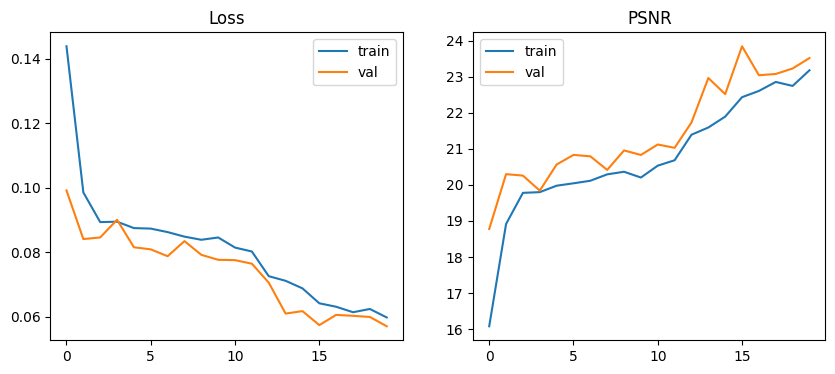

In [31]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['psnr_metrics'], label='train')
plt.plot(history.history['val_psnr_metrics'], label='val')
plt.title("PSNR")
plt.legend()

plt.show()

In [32]:
#Path("../models").mkdir(parents=True, exist_ok=True)

#autoencoder.save("../models/sr_autoencoder.keras")

#print("Model saved.")

In [49]:
ds_test = make_sr_dataset(test_paths,HR_SIZE,SCALE,BATCH,False)
lr,hr = next(iter(ds_test))

In [50]:
pred = autoencoder.predict(lr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [51]:
print(pred.shape)

(8, 128, 128, 3)


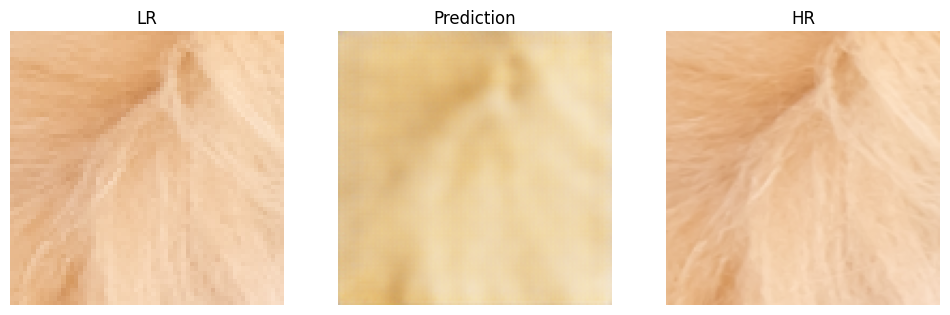

In [52]:
plt.figure(figsize = (12,4))
plt.subplot(1,3,1)
plt.title('LR')
plt.imshow(lr[0])
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Prediction')
plt.imshow(pred[0])
plt.axis('off')

plt.subplot(1,3,3)
plt.title('HR')
plt.imshow(hr[0])
plt.axis('off')

plt.show()